# Weather station groups

- Station locations: `./data/weather_station_location.xlsx`
- Group definitions: `./data/20260323-材料说明.md` (section “原图4-站点分类”)
- Plot style reference: `Fig1/05_weather_stations.ipynb`

This notebook plots the stations in **5 groups** using different colors and saves the map into `./publish/`.

In [1]:
from __future__ import annotations

import re
import warnings
from pathlib import Path

import pandas as pd

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import font_manager

import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# Paths (inputs in ./data, outputs in ./publish)
# NOTE: VS Code notebooks sometimes run with CWD = workspace root.
#       The fallback below makes paths work whether CWD is Fig6/ or its parent.
# ----------------------------------------------------------------------------
DATA_DIR = Path("data")
OUT_DIR = Path("publish")

if not DATA_DIR.is_dir():
    DATA_DIR = Path("Fig6/data")
if not OUT_DIR.is_dir():
    OUT_DIR = Path("Fig6/publish")

OUT_DIR.mkdir(parents=True, exist_ok=True)

STATION_XLSX = DATA_DIR / "weather_station_location.xlsx"
GROUP_MD = DATA_DIR / "20260323-材料说明.md"

_required_inputs = [STATION_XLSX, GROUP_MD]
_missing = [p for p in _required_inputs if not p.exists()]
if _missing:
    raise FileNotFoundError(
        "Missing required input files:\n"
        + "\n".join(f"- {p.as_posix()}" for p in _missing)
        + f"\n\nDetected DATA_DIR={DATA_DIR.resolve().as_posix()}"
    )

print(f"[Paths] DATA_DIR = {DATA_DIR.resolve().as_posix()}")
print(f"[Paths] OUT_DIR  = {OUT_DIR.resolve().as_posix()}")

# ----------------------------------------------------------------------------
# Plot style (follow Fig1/05_weather_stations.ipynb)
# ----------------------------------------------------------------------------
DPI = 600
FONTSIZE = 12

_avail_fonts = {f.name for f in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in _avail_fonts else "DejaVu Sans"

mpl.rcParams.update(
    {
        "font.family": FONT_FAMILY,
        "font.size": FONTSIZE,
        "axes.labelsize": FONTSIZE,
        "xtick.labelsize": FONTSIZE,
        "ytick.labelsize": FONTSIZE,
        "legend.fontsize": FONTSIZE,
    }
)
print(f"[Font] Using: {FONT_FAMILY}")


def save_tiff(fig: "plt.Figure", out_path: Path) -> None:
    """Save a TIFF; tries LZW compression if supported by Pillow."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    common = dict(dpi=DPI, format="tiff", bbox_inches="tight")
    try:
        fig.savefig(out_path, pil_kwargs={"compression": "tiff_lzw"}, **common)
    except TypeError:
        fig.savefig(out_path, **common)


[Paths] DATA_DIR = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/data
[Paths] OUT_DIR  = E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/publish
[Font] Using: Arial


In [2]:
# ----------------------------------------------------------------------------
# Load station locations
# ----------------------------------------------------------------------------

def _pick_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


try:
    station_raw = pd.read_excel(STATION_XLSX, sheet_name=1)
except Exception:
    station_raw = pd.read_excel(STATION_XLSX)

lon_col = _pick_col(station_raw, ["经度", "lon", "longitude", "LON"])
lat_col = _pick_col(station_raw, ["纬度", "lat", "latitude", "LAT"])
code_col = _pick_col(station_raw, ["pfx", "PFX", "code", "CODE", "station", "Station", "abbr", "简称"])

if lon_col is None or lat_col is None or code_col is None:
    raise KeyError(
        "Cannot find required columns for lon/lat/code. "
        f"Available columns: {list(station_raw.columns)}"
    )

stations = (
    station_raw[[lon_col, lat_col, code_col]]
    .rename(columns={lon_col: "lon", lat_col: "lat", code_col: "code"})
    .copy()
)

stations["code"] = stations["code"].astype(str).str.strip().str.upper()
stations["lon"] = pd.to_numeric(stations["lon"], errors="coerce")
stations["lat"] = pd.to_numeric(stations["lat"], errors="coerce")
stations = stations.dropna(subset=["lon", "lat", "code"]).reset_index(drop=True)

stations.head()

,lon,lat,code
0,114.174167,22.301944,HKO
1,113.921944,22.309444,HKA
2,114.210000,22.402500,SHA
3,113.983611,22.468889,LFS
4,114.156667,22.528611,TKL


In [3]:
# ----------------------------------------------------------------------------
# Parse 5 station groups from ./data/20260323-材料说明.md
# ----------------------------------------------------------------------------

md_text = GROUP_MD.read_text(encoding="utf-8", errors="ignore")


def parse_station_groups(md_text: str) -> dict[str, list[str]]:
    lines = md_text.splitlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("## 原图4-站点分类"):
            start_idx = i
            break
    if start_idx is None:
        raise ValueError("Cannot find section '## 原图4-站点分类' in markdown.")

    end_idx = len(lines)
    for i in range(start_idx + 1, len(lines)):
        if lines[i].strip().startswith("## "):
            end_idx = i
            break

    section_lines = lines[start_idx + 1 : end_idx]

    groups: list[tuple[int, str, list[str]]] = []
    for line in section_lines:
        line = line.strip()
        m = re.match(r"^(\d+)\.\s*(.+?)[：:]\s*(.+)$", line)
        if not m:
            continue

        idx = int(m.group(1))
        group_name = m.group(2).strip()
        content = m.group(3).strip().rstrip("；;。.")

        items = re.split(r"[，,、]\s*", content)
        codes: list[str] = []
        for item in items:
            item = item.strip().rstrip("；;。.")
            if not item:
                continue
            m_code = re.search(r"([A-Za-z0-9]+)\s*$", item)
            if m_code:
                codes.append(m_code.group(1).upper())

        groups.append((idx, group_name, codes))

    groups = sorted(groups, key=lambda x: x[0])
    group_dict = {name: codes for _, name, codes in groups}

    if len(group_dict) != 5:
        raise ValueError(
            f"Expected 5 groups, got {len(group_dict)}. Parsed: {list(group_dict.keys())}"
        )

    return group_dict


station_groups = parse_station_groups(md_text)
station_groups

{'城市中心': ['HKO', 'CP1', 'SF', 'NP', 'KP'],
 '低矮建筑加内陆平原': ['TKL', 'SEK', 'WLP', 'SHA'],
 '低矮建筑加海边': ['SKG', 'SHL', 'TPK', 'LFS'],
 '海岛': ['WGL', 'CCH', 'PEN', 'GI', 'SC', 'TMT'],
 '山地加密集森林': ['TMS', 'NLS', 'YTS', 'NGP']}

In [4]:
# ----------------------------------------------------------------------------
# Attach group labels to stations (keep only the 5 groups)
# ----------------------------------------------------------------------------

code_to_group = {code: group for group, codes in station_groups.items() for code in codes}

stations["group"] = stations["code"].map(code_to_group)

missing_in_excel = sorted(set(code_to_group) - set(stations["code"]))
if missing_in_excel:
    print("[Warning] Codes in group list but not in Excel:")
    print(missing_in_excel)

stations_grouped = stations.dropna(subset=["group"]).copy()

unclassified = sorted(set(stations["code"]) - set(stations_grouped["code"]))
if unclassified:
    print(f"[Info] Unclassified stations in Excel (ignored in plot): {len(unclassified)}")
    print(unclassified)

stations_grouped[["code", "group", "lon", "lat"]].sort_values(["group", "code"]).reset_index(drop=True)

[Info] Unclassified stations in Excel (ignored in plot): 7
['HKA', 'HKS', 'JKB', 'PLC', 'SE', 'SLW', 'TME']


,code,group,lon,lat
0,SEK,低矮建筑加内陆平原,114.084722,22.436111
1,SHA,低矮建筑加内陆平原,114.210000,22.402500
2,TKL,低矮建筑加内陆平原,114.156667,22.528611
3,WLP,低矮建筑加内陆平原,114.008889,22.466667
4,LFS,低矮建筑加海边,113.983611,22.468889
5,SHL,低矮建筑加海边,114.086389,22.346667
6,SKG,低矮建筑加海边,114.274444,22.375556
7,TPK,低矮建筑加海边,114.183889,22.442500
8,CP1,城市中心,114.155833,22.288889
9,HKO,城市中心,114.174167,22.301944


[Saved] publish/weather_station_groups.tif


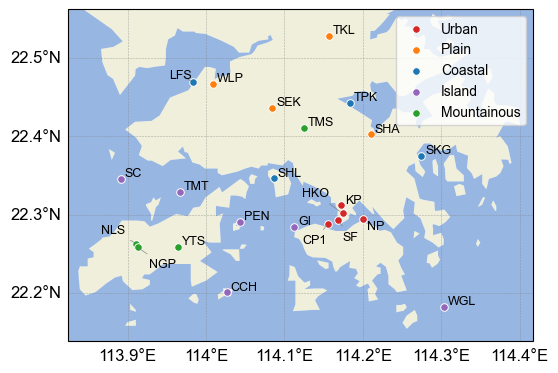

In [5]:
# ----------------------------------------------------------------------------
# Plot stations by group (Cartopy style aligned with Fig1)
# ----------------------------------------------------------------------------

# Domain range (same as Fig1/05_weather_stations.ipynb)
lat_min, lat_max, lon_min, lon_max = (22.139, 22.562, 113.824, 114.417)

group_names = list(station_groups.keys())  # order follows the markdown numbering


def _english_group_label(group_name: str) -> str:
    """English labels for the 5 station groups (legend only)."""
    g = str(group_name)
    if "城市中心" in g:
        return "Urban"
    if "内陆" in g:
        return "Plain"
    if "海边" in g:
        return "Coastal"
    if "海岛" in g:
        return "Island"
    if ("山地" in g) or ("森林" in g):
        return "Mountainous"
    return g


def _group_color(group_name: str) -> str:
    """Fixed group colors (same hue families, nicer shades)."""
    g = str(group_name)
    if "城市中心" in g:
        return mcolors.to_hex("tab:red")
    if "内陆" in g:
        return mcolors.to_hex("tab:orange")
    if "海边" in g:
        return mcolors.to_hex("tab:blue")
    if "海岛" in g:
        return mcolors.to_hex("tab:purple")
    if ("山地" in g) or ("森林" in g):
        return mcolors.to_hex("tab:green")
    return mcolors.to_hex("0.5")


group_labels_en = {g: _english_group_label(g) for g in group_names}
group_colors = {g: _group_color(g) for g in group_names}

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale("10m"))
ax.add_feature(cfeature.OCEAN.with_scale("10m"))
# ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, color="gray", alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12, "family": FONT_FAMILY}
gl.ylabel_style = {"size": 12, "family": FONT_FAMILY}

for g in group_names:
    sub = stations_grouped[stations_grouped["group"] == g]
    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=30,
        color=group_colors[g],
        edgecolor="white",
        linewidth=0.7,
        transform=ccrs.PlateCarree(),
        zorder=3,
        label=group_labels_en.get(g, g),
    )

custom_offsets = {
    "NLS": (-8, 5),
    "NGP": (8, -8),
    "HKO": (-10, 10),
    "LFS": (-1, 1),
    "NP": (3, -1),
    "CP1": (-1, -8),
    "SF": (3, -8),
}

for _, row in stations_grouped.iterrows():
    station_name = str(row["code"]).upper()

    if station_name in custom_offsets:
        offset_x, offset_y = custom_offsets[station_name]
        ha = "left" if offset_x >= 0 else "right"
        va = "bottom" if offset_y >= 0 else "top"
        ax.annotate(
            station_name,
            xy=(row["lon"], row["lat"]),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=9,
            fontfamily=FONT_FAMILY,
            arrowprops={"arrowstyle": "-", "color": "0.45", "lw": 0.4},
            transform=ccrs.PlateCarree(),
            zorder=4,
        )
    else:
        ax.text(
            row["lon"] + 0.005,
            row["lat"] + 0.003,
            station_name,
            fontsize=9,
            fontfamily=FONT_FAMILY,
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

ax.legend(loc="upper right", prop={"family": FONT_FAMILY, "size": 10})

out_path = OUT_DIR / "weather_station_groups.tif"
save_tiff(fig, out_path)
print(f"[Saved] {out_path.as_posix()}")

plt.show()